## Ukraine Railway Open-Source Data Extraction

In [28]:
"""
SOTA: Extract Ukraine Railway Network 
"""

import csv
from collections import defaultdict, deque
import geopandas as gpd
from shapely.geometry import Point

from scgraph_data.world_railways import world_railways_geograph

print("Loading Ukraine boundary shapefile...")
ukraine_boundary_path = 'ne_10m_admin_0_countries.shp'

try:
    world = gpd.read_file(ukraine_boundary_path)
    ukraine_boundary = world[world['NAME'] == 'Ukraine']
    
    if ukraine_boundary.empty:
        use_shapefile = False
    else:
        print(f"Successfully loaded Ukraine boundary")
        ukraine_geom = ukraine_boundary.geometry.iloc[0]
        use_shapefile = True
except FileNotFoundError:
    print(f"Shapefile not found, using bounding box")
    use_shapefile = False
    
    UKRAINE_BOUNDS = {
        'min_lat': 44.0,
        'max_lat': 52.5,
        'min_lon': 22.0,
        'max_lon': 40.5
    }

def is_in_ukraine(lat, lon):
    if use_shapefile:
        point = Point(lon, lat)
        return ukraine_geom.contains(point)
    else:
        return (UKRAINE_BOUNDS['min_lat'] <= lat <= UKRAINE_BOUNDS['max_lat'] and
                UKRAINE_BOUNDS['min_lon'] <= lon <= UKRAINE_BOUNDS['max_lon'])

print("\nExtracting nodes from world railways geograph...")
nodes = world_railways_geograph.nodes
graph = world_railways_geograph.graph

ukraine_node_indices = set()
node_data = {}

for idx, node in enumerate(nodes):
    lat, lon = node[0], node[1]
    if is_in_ukraine(lat, lon):
        ukraine_node_indices.add(idx)
        node_data[idx] = {'latitude': lat, 'longitude': lon}

print(f"Found {len(ukraine_node_indices)} nodes in Ukraine")

# Remove specific nodes --- UPDATE TO TAKE A LIST
NODE_TO_REMOVE = 100462
if NODE_TO_REMOVE in ukraine_node_indices:
    print(f"Removing node {NODE_TO_REMOVE}...")
    ukraine_node_indices.remove(NODE_TO_REMOVE)
    if NODE_TO_REMOVE in node_data:
        del node_data[NODE_TO_REMOVE]

# Extract edges - STORE AS UNDIRECTED, SKIP SELF-LOOPS
print("\nExtracting edges...")
edges = {}  # Use dict with tuple keys for undirected edges

for node_idx in ukraine_node_indices:
    connections = graph[node_idx]
    for connected_node_idx, distance in connections.items():
        if connected_node_idx in ukraine_node_indices:
            # Skip self-loops
            if node_idx == connected_node_idx:
                continue
            # Store as undirected edge
            edge_key = tuple(sorted([node_idx, connected_node_idx]))
            if edge_key not in edges:
                edges[edge_key] = distance

print(f"Found {len(edges)} undirected edges")

# Build undirected adjacency list
adjacency = defaultdict(set)
edge_distances = {}

for (node1, node2), distance in edges.items():
    adjacency[node1].add(node2)
    adjacency[node2].add(node1)
    edge_distances[(node1, node2)] = distance
    edge_distances[(node2, node1)] = distance

# Find connected components
def find_connected_components(adjacency):
    visited = set()
    components = []
    
    for start_node in adjacency:
        if start_node not in visited:
            component = set()
            queue = deque([start_node])
            
            while queue:
                node = queue.popleft()
                if node in visited:
                    continue
                visited.add(node)
                component.add(node)
                for neighbor in adjacency[node]:
                    if neighbor not in visited:
                        queue.append(neighbor)
            components.append(component)
    
    return components

print("\nFinding connected components...")
components = find_connected_components(adjacency)
print(f"Found {len(components)} connected component(s)")

for i, component in enumerate(sorted(components, key=len, reverse=True), 1):
    print(f"  Component {i}: {len(component)} nodes")

# Keep only largest component
if len(components) > 1:
    largest_component = max(components, key=len)
    nodes_to_remove = set()
    for component in components:
        if component != largest_component:
            nodes_to_remove.update(component)
    
    print(f"\nRemoving {len(nodes_to_remove)} nodes from smaller components...")
    
    for node in nodes_to_remove:
        if node in adjacency:
            del adjacency[node]
        if node in node_data:
            del node_data[node]
    
    # Remove edges involving removed nodes
    edges_to_remove = []
    for (n1, n2) in edges:
        if n1 in nodes_to_remove or n2 in nodes_to_remove:
            edges_to_remove.append((n1, n2))
    
    for edge_key in edges_to_remove:
        del edges[edge_key]
    
    # Rebuild adjacency
    adjacency = defaultdict(set)
    edge_distances = {}
    for (node1, node2), distance in edges.items():
        adjacency[node1].add(node2)
        adjacency[node2].add(node1)
        edge_distances[(node1, node2)] = distance
        edge_distances[(node2, node1)] = distance

# Check degree distribution
print("\nDegree distribution BEFORE simplification:")
degree_dist = defaultdict(int)
for node in adjacency:
    degree_dist[len(adjacency[node])] += 1
for degree in sorted(degree_dist.keys()):
    print(f"  Degree {degree}: {degree_dist[degree]} nodes")

print(f"\n>>> Starting with {degree_dist.get(2, 0)} degree-2 nodes <<<")

# Remove degree-2 nodes - WITH SELF-LOOP PREVENTION
print("\nSimplifying network...")
removed_count = 0
skipped_self_loops = 0

for iteration in range(1, 50000):
    # Find degree-2 nodes
    degree_2_nodes = [node for node in adjacency if len(adjacency[node]) == 2]
    
    if not degree_2_nodes:
        print(f"\n>>> SUCCESS: No more degree-2 nodes after {iteration-1} iterations <<<")
        break
    
    if iteration % 500 == 1:
        print(f"  Iteration {iteration}: {len(degree_2_nodes)} degree-2 nodes remaining...")
    
    # Process first degree-2 node
    node_to_remove = degree_2_nodes[0]
    neighbors = list(adjacency[node_to_remove])
    n1, n2 = neighbors[0], neighbors[1]
    
    # CRITICAL: Skip if neighbors are the same (would create self-loop)
    if n1 == n2:
        print(f"  Warning: Node {node_to_remove} has duplicate neighbor {n1}, removing without reconnection")
        # Just remove this node without creating new edges
        adjacency[n1].discard(node_to_remove)
        del adjacency[node_to_remove]
        if node_to_remove in node_data:
            del node_data[node_to_remove]
        
        # Remove from edges
        old_edge = tuple(sorted([node_to_remove, n1]))
        if old_edge in edges:
            del edges[old_edge]
        
        skipped_self_loops += 1
        continue
    
    # Get distances
    dist1 = edge_distances.get((node_to_remove, n1), 0)
    dist2 = edge_distances.get((node_to_remove, n2), 0)
    combined_distance = dist1 + dist2
    
    # Remove from adjacency
    adjacency[n1].discard(node_to_remove)
    adjacency[n2].discard(node_to_remove)
    del adjacency[node_to_remove]
    
    # Remove from node_data
    if node_to_remove in node_data:
        del node_data[node_to_remove]
    
    # Remove old edges
    old_edge1 = tuple(sorted([node_to_remove, n1]))
    old_edge2 = tuple(sorted([node_to_remove, n2]))
    if old_edge1 in edges:
        del edges[old_edge1]
    if old_edge2 in edges:
        del edges[old_edge2]
    
    # Add new edge between neighbors (NO SELF-LOOPS!)
    new_edge_key = tuple(sorted([n1, n2]))
    if new_edge_key in edges:
        edges[new_edge_key] = min(edges[new_edge_key], combined_distance)
    else:
        edges[new_edge_key] = combined_distance
    
    # Update adjacency
    adjacency[n1].add(n2)
    adjacency[n2].add(n1)
    
    # Update edge distances
    edge_distances[(n1, n2)] = edges[new_edge_key]
    edge_distances[(n2, n1)] = edges[new_edge_key]
    
    removed_count += 1

print(f"\nTotal degree-2 nodes removed: {removed_count}")
print(f"Skipped self-loop cases: {skipped_self_loops}")

# VERIFY NO SELF-LOOPS IN FINAL EDGES
self_loops_in_edges = [(n1, n2) for (n1, n2) in edges if n1 == n2]
if self_loops_in_edges:
    print(f"\n!!! ERROR: {len(self_loops_in_edges)} self-loops found in edges !!!")
else:
    print("\n>>> VERIFIED: No self-loops in edges <<<")

# FINAL VERIFICATION
print("\n>>> FINAL VERIFICATION <<<")
final_adjacency_check = defaultdict(set)
for (n1, n2) in edges:
    final_adjacency_check[n1].add(n2)
    final_adjacency_check[n2].add(n1)

final_deg_2 = sum(1 for n in final_adjacency_check if len(final_adjacency_check[n]) == 2)
print(f"Degree-2 nodes in final network: {final_deg_2}")

print("\nDegree distribution AFTER simplification:")
degree_dist_final = defaultdict(int)
for node in final_adjacency_check:
    degree_dist_final[len(final_adjacency_check[node])] += 1
for degree in sorted(degree_dist_final.keys()):
    print(f"  Degree {degree}: {degree_dist_final[degree]} nodes")

# Prepare data for CSV
simplified_nodes = [
    {
        'node_id': node_id,
        'latitude': node_data[node_id]['latitude'],
        'longitude': node_data[node_id]['longitude']
    }
    for node_id in sorted(node_data.keys())
]

# NO SELF-LOOPS in edges!
simplified_edges = [
    {
        'source_node_id': n1,
        'destination_node_id': n2,
        'distance_km': dist
    }
    for (n1, n2), dist in sorted(edges.items())
    if n1 != n2  # Extra safety check
]

print(f"\nSaving {len(simplified_nodes)} nodes and {len(simplified_edges)} edges...")

with open('ukraine_railway_nodes.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['node_id', 'latitude', 'longitude'])
    writer.writeheader()
    writer.writerows(simplified_nodes)

with open('ukraine_railway_edges.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['source_node_id', 'destination_node_id', 'distance_km'])
    writer.writeheader()
    writer.writerows(simplified_edges)

print("\nExtraction complete!")
print(f"Saved {len(simplified_nodes)} nodes and {len(simplified_edges)} edges")
print("NO self-loops, NO degree-2 nodes!")


Loading Ukraine boundary shapefile...
Successfully loaded Ukraine boundary

Extracting nodes from world railways geograph...
Found 4821 nodes in Ukraine
Removing node 100462...

Extracting edges...
Found 5686 undirected edges

Finding connected components...
Found 17 connected component(s)
  Component 1: 4126 nodes
  Component 2: 519 nodes
  Component 3: 36 nodes
  Component 4: 29 nodes
  Component 5: 22 nodes
  Component 6: 22 nodes
  Component 7: 11 nodes
  Component 8: 10 nodes
  Component 9: 10 nodes
  Component 10: 6 nodes
  Component 11: 6 nodes
  Component 12: 4 nodes
  Component 13: 4 nodes
  Component 14: 4 nodes
  Component 15: 3 nodes
  Component 16: 3 nodes
  Component 17: 2 nodes

Removing 691 nodes from smaller components...

Degree distribution BEFORE simplification:
  Degree 1: 226 nodes
  Degree 2: 2645 nodes
  Degree 3: 934 nodes
  Degree 4: 241 nodes
  Degree 5: 47 nodes
  Degree 6: 21 nodes
  Degree 7: 7 nodes
  Degree 8: 3 nodes
  Degree 9: 2 nodes

>>> Starting wi

Reading railway nodes...
Reading railway edges...
Loaded 1379 nodes and 2040 edges
Converting coordinates to Web Mercator projection...
Plotting railway connections...
Plotting railway stations/junctions...
Adding background map...

Map saved as: ukraine_railway_network_with_map.png


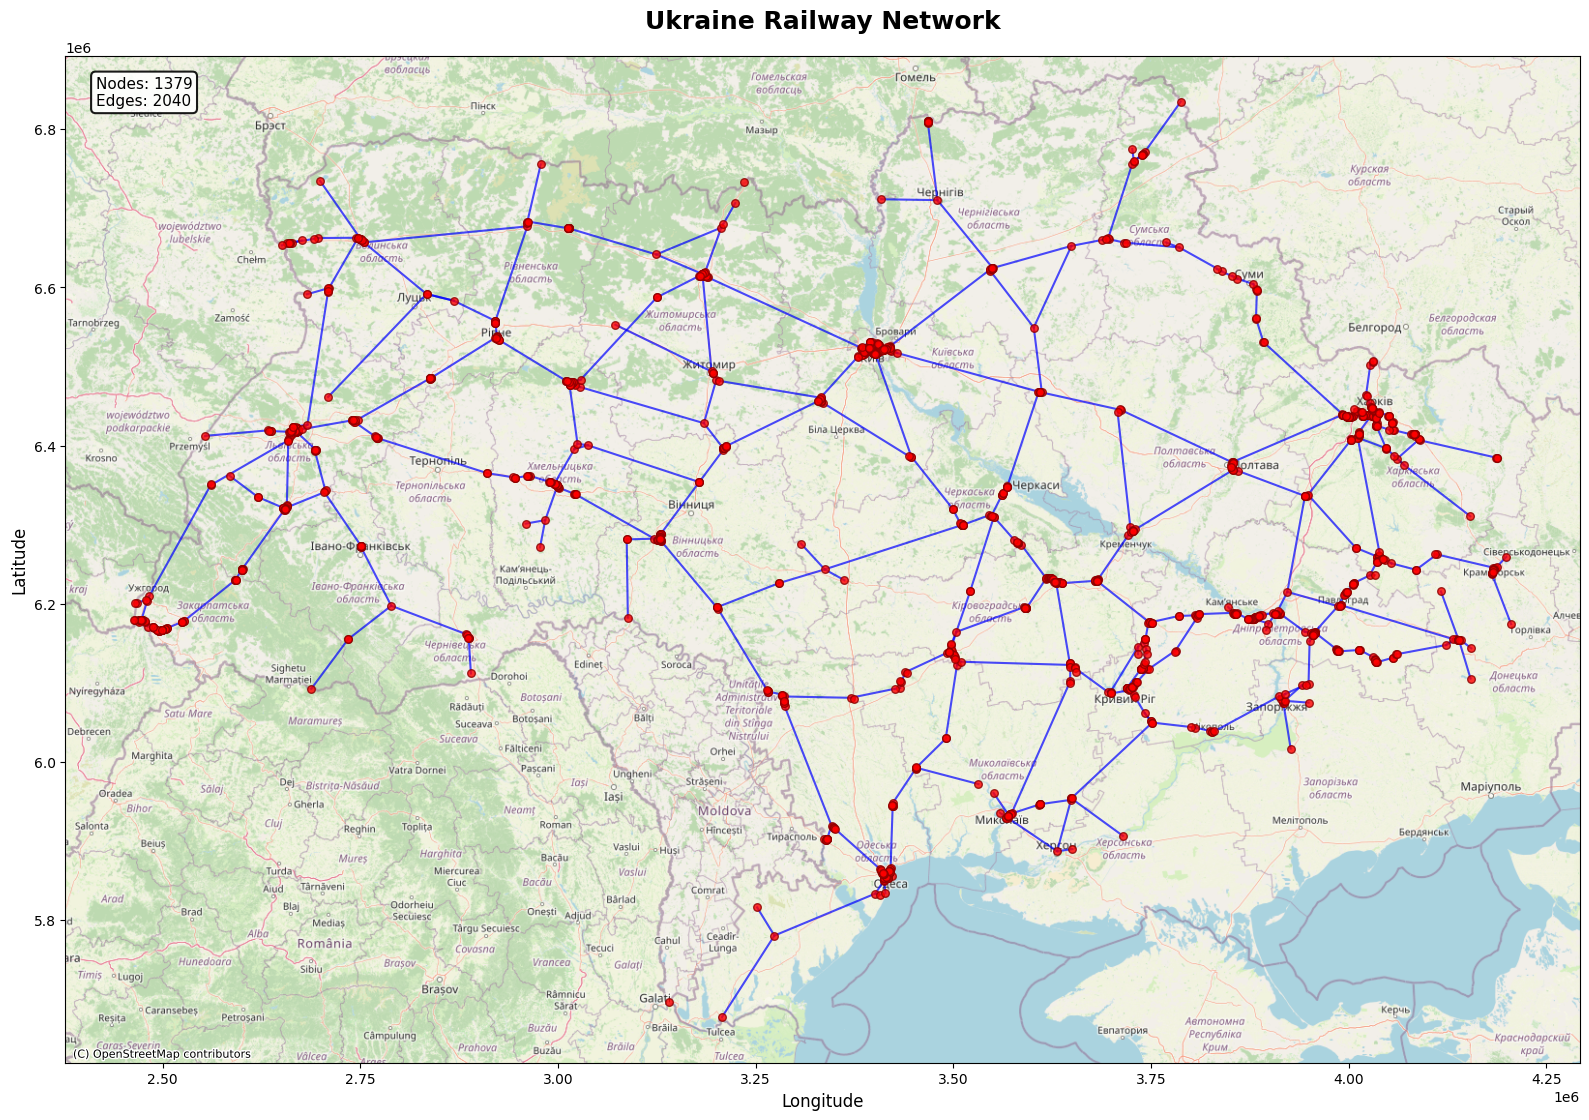


Visualization complete!


In [29]:
"""
Plot Ukraine Railway Network with Map Background
This script reads the extracted CSV files and creates a visualization
of the railway network overlaid on a real map of Ukraine.
"""

import csv
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.patches import Rectangle

# Read nodes from CSV
print("Reading railway nodes...")
nodes = []
with open('ukraine_railway_nodes.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        nodes.append({
            'node_id': int(row['node_id']),
            'latitude': float(row['latitude']),
            'longitude': float(row['longitude'])
        })

# Read edges from CSV
print("Reading railway edges...")
edges = []
with open('ukraine_railway_edges.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        edges.append({
            'source': int(row['source_node_id']),
            'destination': int(row['destination_node_id']),
            'distance': float(row['distance_km'])
        })

print(f"Loaded {len(nodes)} nodes and {len(edges)} edges")

# Function to convert lat/lon to Web Mercator (EPSG:3857)
def lat_lon_to_web_mercator(lat, lon):
    """Convert latitude/longitude to Web Mercator projection"""
    import math
    x = lon * 20037508.34 / 180.0
    y = math.log(math.tan((90 + lat) * math.pi / 360.0)) / (math.pi / 180.0)
    y = y * 20037508.34 / 180.0
    return x, y

# Convert all coordinates to Web Mercator
print("Converting coordinates to Web Mercator projection...")
node_coords_mercator = {}
for node in nodes:
    x, y = lat_lon_to_web_mercator(node['latitude'], node['longitude'])
    node_coords_mercator[node['node_id']] = (x, y)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 12))

# Plot edges first (so they appear behind nodes)
print("Plotting railway connections...")
for edge in edges:
    source_id = edge['source']
    dest_id = edge['destination']
    
    if source_id in node_coords_mercator and dest_id in node_coords_mercator:
        source_x, source_y = node_coords_mercator[source_id]
        dest_x, dest_y = node_coords_mercator[dest_id]
        
        # Draw line between nodes
        ax.plot([source_x, dest_x], [source_y, dest_y], 
                'b-', linewidth=1.5, alpha=0.7, zorder=2)

# Plot nodes
print("Plotting railway stations/junctions...")
x_coords = [node_coords_mercator[node['node_id']][0] for node in nodes]
y_coords = [node_coords_mercator[node['node_id']][1] for node in nodes]
ax.scatter(x_coords, y_coords, c='red', s=30, alpha=0.8, zorder=3, 
           edgecolors='darkred', linewidths=1)

# Add background map using contextily
print("Adding background map...")
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=7)

# Set labels and title
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Ukraine Railway Network', fontsize=18, fontweight='bold', pad=20)

# Add statistics text box
stats_text = f'Nodes: {len(nodes)}\nEdges: {len(edges)}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5),
        zorder=4)

# Adjust layout
plt.tight_layout()

# Save the figure
output_file = 'ukraine_railway_network_with_map.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\nMap saved as: {output_file}")

# Show the plot
plt.show()

print("\nVisualization complete!")


In [31]:
"""
Interactive Ukraine Railway Network Map
This script creates an interactive map where you can click on nodes to see their node IDs.
"""

import csv
import folium
from folium import plugins

# Read nodes from CSV
print("Reading railway nodes...")
nodes = []
with open('ukraine_railway_nodes.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        nodes.append({
            'node_id': int(row['node_id']),
            'latitude': float(row['latitude']),
            'longitude': float(row['longitude'])
        })

# Read edges from CSV
print("Reading railway edges...")
edges = []
with open('ukraine_railway_edges.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        edges.append({
            'source': int(row['source_node_id']),
            'destination': int(row['destination_node_id']),
            'distance': float(row['distance_km'])
        })

print(f"Loaded {len(nodes)} nodes and {len(edges)} edges")

# Create a mapping from node_id to coordinates
node_coords = {node['node_id']: (node['latitude'], node['longitude']) for node in nodes}

# Calculate center of map (average of all coordinates)
avg_lat = sum(node['latitude'] for node in nodes) / len(nodes)
avg_lon = sum(node['longitude'] for node in nodes) / len(nodes)

# Create the map centered on Ukraine
print("Creating interactive map...")
railway_map = folium.Map(
    location=[avg_lat, avg_lon],
    zoom_start=6,
    tiles='OpenStreetMap'
)

# Add railway lines (edges) to a feature group
edges_group = folium.FeatureGroup(name='Railway Lines')

for edge in edges:
    source_id = edge['source']
    dest_id = edge['destination']
    
    if source_id in node_coords and dest_id in node_coords:
        source_lat, source_lon = node_coords[source_id]
        dest_lat, dest_lon = node_coords[dest_id]
        
        # Create line between nodes with popup showing edge info
        folium.PolyLine(
            locations=[[source_lat, source_lon], [dest_lat, dest_lon]],
            color='blue',
            weight=2,
            opacity=0.6,
            popup=folium.Popup(
                f'<b>Edge</b><br>From: Node {source_id}<br>To: Node {dest_id}<br>Distance: {edge["distance"]:.2f} km',
                max_width=200
            ),
            tooltip=f'Distance: {edge["distance"]:.1f} km'
        ).add_to(edges_group)

edges_group.add_to(railway_map)

# Add railway nodes to a feature group with clickable markers
nodes_group = folium.FeatureGroup(name='Railway Nodes')

for node in nodes:
    # Create detailed popup HTML
    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px;">
        <h4 style="margin-bottom: 10px;">Railway Node</h4>
        <table style="width: 100%;">
            <tr>
                <td><b>Node ID:</b></td>
                <td>{node['node_id']}</td>
            </tr>
            <tr>
                <td><b>Latitude:</b></td>
                <td>{node['latitude']:.6f}</td>
            </tr>
            <tr>
                <td><b>Longitude:</b></td>
                <td>{node['longitude']:.6f}</td>
            </tr>
        </table>
    </div>
    """
    
    # Create marker with popup and tooltip
    folium.CircleMarker(
        location=[node['latitude'], node['longitude']],
        radius=5,
        color='darkred',
        fill=True,
        fillColor='red',
        fillOpacity=0.8,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"<b>Node ID: {node['node_id']}</b><br>Click for details"
    ).add_to(nodes_group)

nodes_group.add_to(railway_map)

# Add layer control to toggle nodes and edges
folium.LayerControl().add_to(railway_map)

# Add fullscreen button
plugins.Fullscreen(
    position='topleft',
    title='Fullscreen',
    title_cancel='Exit Fullscreen',
    force_separate_button=True
).add_to(railway_map)

# Add mouse position display
plugins.MousePosition().add_to(railway_map)

# Add title and statistics
title_html = f"""
<div style="position: fixed; 
     top: 10px; left: 50px; width: 350px; height: 110px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px; border-radius: 5px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
     <h3 style="margin: 0 0 10px 0;">Ukraine Railway Network</h3>
     <b>Nodes:</b> {len(nodes)}<br>
     <b>Edges:</b> {len(edges)}<br>
     <i style="font-size: 11px; color: #666;">Click on any node to see its ID</i>
</div>
"""
railway_map.get_root().html.add_child(folium.Element(title_html))

# Add search functionality for node IDs
search_html = """
<div style="position: fixed; 
     top: 140px; left: 50px; width: 350px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 10px; border-radius: 5px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
     <b>Quick Tips:</b><br>
     • Click on red nodes to see Node ID<br>
     • Click on blue lines to see edge details<br>
     • Use layer control (top right) to toggle elements<br>
     • Use mouse wheel to zoom in/out
</div>
"""
railway_map.get_root().html.add_child(folium.Element(search_html))

# Save the map
output_file = 'ukraine_railway_interactive_map.html'
railway_map.save(output_file)
print(f"\nInteractive map saved as: {output_file}")
print("Open this file in a web browser to explore the railway network!")
print("\nFeatures:")
print("- Click on any node to see its Node ID and coordinates")
print("- Click on any edge to see connection details")
print("- Toggle layers on/off using the control in the top-right")
print("- Use fullscreen mode for better viewing")
print("- Mouse position shows lat/lon coordinates")


Reading railway nodes...
Reading railway edges...
Loaded 1379 nodes and 2040 edges
Creating interactive map...

Interactive map saved as: ukraine_railway_interactive_map.html
Open this file in a web browser to explore the railway network!

Features:
- Click on any node to see its Node ID and coordinates
- Click on any edge to see connection details
- Toggle layers on/off using the control in the top-right
- Use fullscreen mode for better viewing
- Mouse position shows lat/lon coordinates
